# 03 · Modelo final, escoragem e faixas de score

1. Retreinar o campeão com a Base A inteira (2022–24) e decidir a calibração
2. Escorar a Base B e gravar a submissão
3. Montar as faixas 1–10 e a perda esperada por faixa
4. Escorar a Base C para a política
5. Explicar o modelo: variáveis que mais pesam e como a PD reage a elas
6. Gravar as saídas

In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

from autocred import dados, escoragem, faixas, modelos
from autocred.avaliacao import dependencia_parcial, mascaras_janela

SAIDAS = dados.PASTA_SAIDAS
with open(SAIDAS / "campeao.json", encoding="utf-8") as arquivo:
    campeao = json.load(arquivo)
descricao = campeao["descricao"]
conjunto_b = campeao["conjunto_b"]

A = dados.carregar_base("A")
B = dados.carregar_base("B")
C = dados.carregar_base("C")
anos = dados.ano(A)
y = A[dados.ALVO].to_numpy()
y_2024 = y[anos == 2024]
print(f"Campeão: {campeao['candidato']} | Base B usa o conjunto: {conjunto_b}")

Campeão: lightgbm_monotonico | Base B usa o conjunto: portatil


## 1. Retreino e calibração

Primeiro medimos mais uma vez fora do tempo (J1 e J2). Depois treinamos com **toda** a Base A: agora que a
nota foi medida, não há por que esconder 2024, o ano mais parecido com 2025.

**Calibração:** o AUC só mede ordenação, mas a política precisa da PD no nível certo. A curva abaixo compara,
em cada decil de 2024, a PD prevista com a inadimplência que de fato aconteceu. A inclinação ideal é 1.

{'auc_J1': 0.7239, 'ks_J1': 0.3613, 'auc_J2': 0.7498, 'ks_J2': 0.4038, 'auc_medio': 0.7369, 'conjunto': 'portatil', 'inclinacao_J2': 1.0755, 'calibrado': False}


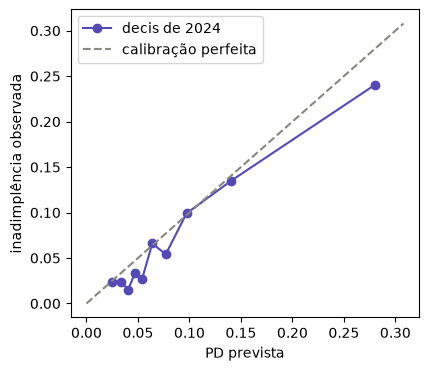

In [2]:
modelo_portatil, info_portatil, prev_portatil = modelos.treinar_final(descricao, A, y, anos, "portatil")
if conjunto_b == "completo":
    modelo_b, info_b, _ = modelos.treinar_final(descricao, A, y, anos, "completo")
else:
    modelo_b, info_b = modelo_portatil, info_portatil
print({k: round(v, 4) if isinstance(v, float) else v for k, v in info_portatil.items()})

p_j2 = prev_portatil["J2"]
decil = faixas.atribuir_score(p_j2, faixas.cortes_decis(p_j2))
curva = pd.DataFrame({"prevista": p_j2, "observada": y_2024}).groupby(decil).mean()
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.plot(curva["prevista"], curva["observada"], "o-", color="#534AB7", label="decis de 2024")
limite = float(curva.max().max()) * 1.1
ax.plot([0, limite], [0, limite], "--", color="#888780", label="calibração perfeita")
ax.set_xlabel("PD prevista")
ax.set_ylabel("inadimplência observada")
ax.legend()
plt.show()

## 2. Submissão da Base B

In [3]:
p_b_submissao = escoragem.prever(modelo_b, B, conjunto_b)
submissao = escoragem.salvar_submissao_b(B["id_contrato"], p_b_submissao, B, SAIDAS / "submissao_modelo_base_B.csv")
display(submissao.head())
print(f"PD média na Base B: {submissao['pd'].mean():.4f}")

,id_contrato,pd
0,T000001,0.047801
1,T000002,0.044804
2,T000003,0.092221
3,T000004,0.035502
4,T000005,0.124113


PD média na Base B: 0.0784


## 3. Faixas 1–10 e perda esperada

Os cortes são os **decis da PD na Base B**, a carteira aprovada mais recente: cada faixa fica com 10% dela.
Score 1 = maior risco, 10 = menor. A coluna `inadimplencia_observada_J2` mostra o que aconteceu de verdade em
2024 no decil equivalente (modelo treinado só até 2023). É a prova de que a ordenação se sustenta.

**Perda esperada (% do valor financiado) = PD × fator de EAD × LGD.** É o piso que a taxa da faixa precisa cobrir.

,qtd,pd_min,pd_max,pd_media,fator_ead_medio,lgd_media,perda_esperada_pct_media,inadimplencia_observada_J2,qtd_base_C,pct_fora_perfil_C
score_1a10,,,,,,,,,,
1,300,0.147963,0.766551,0.248588,1.033457,0.696853,0.180256,0.240240,1779,0.784148
2,300,0.102567,0.147905,0.121774,1.026573,0.686577,0.085954,0.135135,546,0.439560
3,300,0.078960,0.102555,0.089549,1.026897,0.680837,0.062616,0.099099,434,0.322581
4,300,0.065187,0.078776,0.071813,1.024877,0.671210,0.049392,0.054054,398,0.216080
5,300,0.056045,0.065147,0.060507,1.024927,0.671847,0.041692,0.066066,302,0.125828
6,300,0.047842,0.056009,0.051897,1.023970,0.668007,0.035524,0.027027,360,0.091667
7,300,0.041253,0.047831,0.044392,1.023917,0.657553,0.029902,0.033033,299,0.056856
8,300,0.035392,0.041246,0.038295,1.023760,0.668450,0.026220,0.015015,274,0.051095
9,300,0.029412,0.035386,0.032326,1.022667,0.649727,0.021509,0.024024,301,0.026578


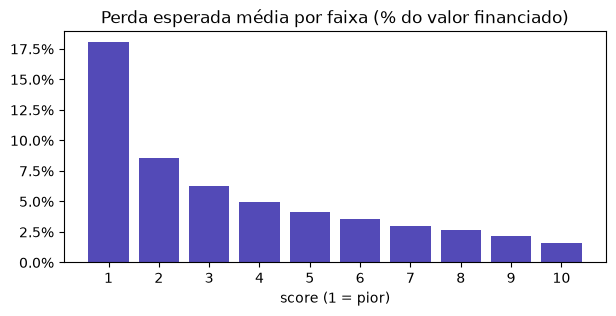

In [4]:
p_b_portatil = escoragem.prever(modelo_portatil, B)
cortes = faixas.cortes_decis(p_b_portatil)
escorada_b = escoragem.escorar(modelo_portatil, B, cortes)
tabela = faixas.tabela_faixas(escorada_b)
tabela["inadimplencia_observada_J2"] = faixas.inadimplencia_por_decil(y_2024, p_j2)
resultado_c = escoragem.prever_pd(modelo_portatil, C, cortes)
tabela["qtd_base_C"] = resultado_c["score_1a10"].value_counts().reindex(range(1, 11), fill_value=0)
tabela["pct_fora_perfil_C"] = resultado_c.groupby("score_1a10")["fora_perfil_historico"].mean().reindex(range(1, 11))
display(tabela)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(tabela.index, tabela["perda_esperada_pct_media"], color="#534AB7")
ax.set_xticks(range(1, 11))
ax.set_xlabel("score (1 = pior)")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.1%}")
ax.set_title("Perda esperada média por faixa (% do valor financiado)")
plt.show()

### Alternativa para discutir com a política: faixas por PD em escala geométrica

Em vez de 10% da carteira por faixa, cada faixa multiplica a PD pelo mesmo fator. As pontas ficam mais
"puras" (menos gente, risco mais homogêneo) e o meio fica mais cheio.

In [5]:
cortes_geo = faixas.cortes_geometricos(p_b_portatil.min(), p_b_portatil.max())
alternativa = pd.DataFrame({
    "qtd_B_decis": pd.Series(faixas.atribuir_score(p_b_portatil, cortes)).value_counts(),
    "qtd_B_geometrica": pd.Series(faixas.atribuir_score(p_b_portatil, cortes_geo)).value_counts(),
    "qtd_C_geometrica": pd.Series(faixas.atribuir_score(resultado_c["pd"], cortes_geo)).value_counts(),
}).reindex(range(1, 11)).fillna(0).astype(int)
display(alternativa)

,qtd_B_decis,qtd_B_geometrica,qtd_C_geometrica
1,300,9,105
2,300,37,375
3,300,95,645
4,300,156,652
5,300,345,624
6,300,562,758
7,300,800,862
8,300,730,718
9,300,249,240
10,300,17,21


## 4. Base C: o que muda no mar aberto

A PD da Base C foi calculada nas condições que o cliente pediu (prazo e entrada desejados, com taxa de
referência de 1,589% a.m.). Repare quanta gente cai nas faixas 1–3, e quantos estão **fora do perfil
histórico**: para esses, a PD é extrapolação e merece margem de segurança.

In [6]:
print(f"PD média | Base B: {p_b_portatil.mean():.4f} | Base C: {resultado_c['pd'].mean():.4f}")
print(f"Base C fora do perfil histórico: {resultado_c['fora_perfil_historico'].mean():.1%}")
display(resultado_c.head())

PD média | Base B: 0.0784 | Base C: 0.1445
Base C fora do perfil histórico: 39.5%


,id_proposta,pd,score_1a10,fator_ead,ead,lgd,perda_esperada,perda_esperada_pct,ltv_ofertado,prazo_meses,taxa_am,fora_perfil_historico
0,P000001,0.225628,1,1.042,22007.04000,0.826,4101.424011,0.194196,0.9600,60,0.01589,True
1,P000002,0.053787,6,1.038,42153.60558,0.736,1668.751409,0.041092,0.9293,48,0.01589,False
2,P000003,0.015876,10,0.995,16483.17000,0.900,235.522282,0.014217,0.7530,24,0.01589,False
3,P000004,0.108449,2,1.027,34280.43840,0.847,3148.872529,0.094336,0.9272,36,0.01589,True
4,P000005,0.399601,1,1.042,71170.07964,0.664,18883.910189,0.276479,0.9526,60,0.01589,True


## 5. Explicando o modelo

**Importância por permutação:** embaralhamos uma variável de cada vez em 2024 e medimos quanto o AUC cai.
Quanto maior a queda, mais o modelo depende dela. Usamos o modelo treinado até 2023 para medir em dado
que ele não viu.

,variavel,queda_auc,desvio
0,idade_cliente,0.090491,0.005755
1,prazo_meses,0.070367,0.012075
2,score_bureau,0.040780,0.002936
3,comprometimento_renda,0.039939,0.004524
4,tempo_emprego_meses,0.017729,0.004920
5,qtd_restricoes_ativas,0.017239,0.004946
6,ocupacao,0.015748,0.004434
7,ltv,0.004126,0.001749
8,idade_veiculo_anos,0.003477,0.001516
9,tipo_residencia,0.002716,0.000856


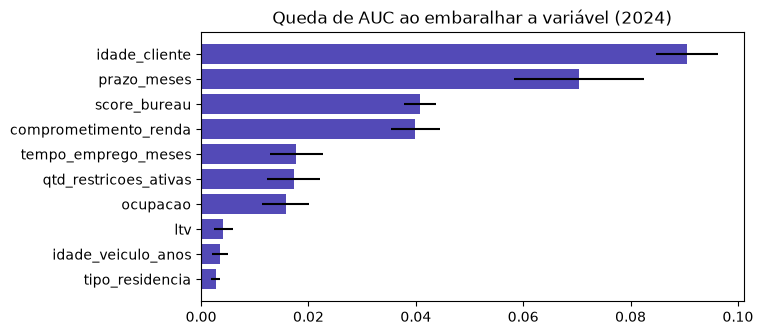

In [7]:
X_portatil = A[dados.colunas_entrada("portatil")]
treino_j2, teste_j2 = mascaras_janela(anos, "J2")
modelo_j2 = modelos.construir_modelo(descricao, "portatil").fit(X_portatil.loc[treino_j2], y[treino_j2])
perm = permutation_importance(
    modelo_j2, X_portatil.loc[teste_j2], y_2024, scoring="roc_auc", n_repeats=10, random_state=modelos.SEMENTE
)
importancias = (
    pd.DataFrame({"variavel": X_portatil.columns, "queda_auc": perm.importances_mean, "desvio": perm.importances_std})
    .sort_values("queda_auc", ascending=False)
    .reset_index(drop=True)
)
display(importancias.head(10))

top = importancias.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(top["variavel"], top["queda_auc"], xerr=top["desvio"], color="#534AB7")
ax.set_title("Queda de AUC ao embaralhar a variável (2024)")
plt.show()

**Dependência parcial:** como a PD média da carteira muda quando mexemos só em uma variável. É a resposta
para "o que acontece com o risco se o LTV sobe?".

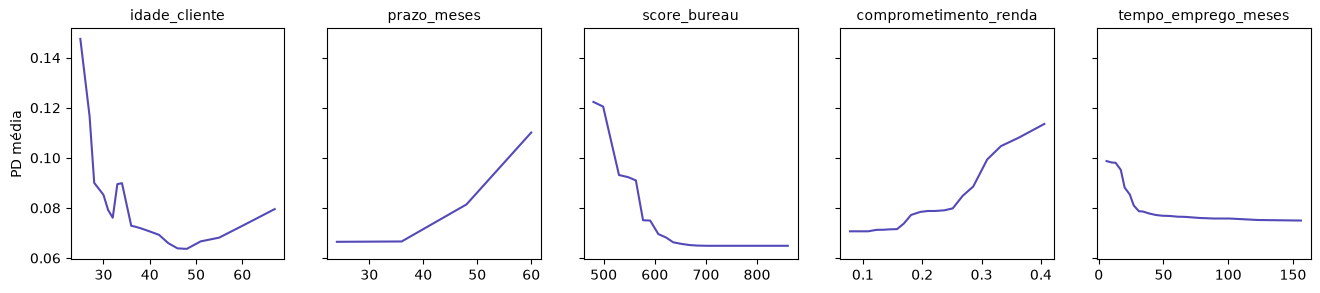

In [8]:
amostra = X_portatil.sample(2000, random_state=modelos.SEMENTE)
principais = importancias["variavel"].head(5).tolist()
fig, eixos = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
for eixo, coluna in zip(eixos, principais):
    curva_dp = dependencia_parcial(modelo_portatil, amostra, coluna)
    if pd.api.types.is_numeric_dtype(amostra[coluna]):
        eixo.plot(curva_dp["valor"], curva_dp["pd_media"], color="#534AB7")
    else:
        eixo.bar(curva_dp["valor"].astype(str), curva_dp["pd_media"], color="#534AB7")
        eixo.tick_params(axis="x", rotation=45)
    eixo.set_title(coluna, fontsize=10)
eixos[0].set_ylabel("PD média")
plt.show()

## 6. Gravando as saídas

In [9]:
tabela.to_csv(SAIDAS / "faixas_score.csv", encoding="utf-8")

leia_me = pd.DataFrame(
    [
        ("pd", "PD 90/12 estimada nas condições pedidas pelo cliente (prazo e entrada desejados), taxa de referência 1,589% a.m."),
        ("score_1a10", "1 = maior risco, 10 = menor. Cortes = decis da PD na Base B (carteira aprovada mais recente)."),
        ("fator_ead / ead", "Tabela do desafio por prazo e faixa de LTV (faixas fechadas à esquerda: 60% cai em 60–70%)."),
        ("lgd", "Tabela do desafio por idade do veículo e faixa de LTV; −0,061 quando há avalista."),
        ("perda_esperada", "PD × EAD × LGD, em R$; perda_esperada_pct = em % do valor financiado."),
        ("fora_perfil_historico", "Score de bureau < 460, mais de 2 restrições ou LTV > 95%: perfil que o modelo nunca viu."),
        ("Alerta 1", "O modelo não enxerga a seleção adversa da taxa: taxa alta tende a elevar a PD real além da prevista."),
        ("Alerta 2", "Para propostas fora do perfil histórico, a PD é extrapolação; use margem de segurança."),
        ("Alerta 3", "Na Base C o comprometimento de renda foi recalculado com a taxa de referência; sem renda, foi imputado."),
        ("Recalcular", "escoragem.prever_pd(modelo, propostas, cortes, taxa_am, prazo_meses, pct_entrada_minima) com saidas/modelo_pd.joblib."),
    ],
    columns=["item", "descricao"],
)
with pd.ExcelWriter(SAIDAS / "base_C_escorada.xlsx", engine="openpyxl") as planilha:
    resultado_c.to_excel(planilha, sheet_name="propostas", index=False)
    tabela.reset_index().to_excel(planilha, sheet_name="faixas", index=False)
    leia_me.to_excel(planilha, sheet_name="leia_me", index=False)

joblib.dump(
    {"modelo_portatil": modelo_portatil, "modelo_b": modelo_b, "conjunto_b": conjunto_b, "cortes": cortes, "descricao": descricao},
    SAIDAS / "modelo_pd.joblib",
)

resultados = {
    "campeao": campeao,
    "info_portatil": info_portatil,
    "info_b": info_b,
    "cortes": cortes.tolist(),
    "faixas": tabela.reset_index().to_dict("records"),
    "importancias": importancias.head(10).to_dict("records"),
    "pd_media_A": float(escoragem.prever(modelo_portatil, A).mean()),
    "pd_media_B": float(p_b_portatil.mean()),
    "pd_media_C": float(resultado_c["pd"].mean()),
    "inadimplencia_2024": float(y_2024.mean()),
    "pct_fora_perfil_C": float(resultado_c["fora_perfil_historico"].mean()),
}
with open(SAIDAS / "resultados_modelo.json", "w", encoding="utf-8") as arquivo:
    json.dump(resultados, arquivo, ensure_ascii=False, indent=2)

assert len(submissao) == 3000 and len(resultado_c) == 5000
assert resultado_c["score_1a10"].between(1, 10).all()
print("Saídas gravadas em saidas/")

Saídas gravadas em saidas/
